# 04_Elo_rating.ipynb

The objective of this notebook is to explore the Elo rating system.

We can use game data for a single season to compute their Elo strength at the end of the season. This information could then be used for playoff bracket simulations.

- Input: List of all games in a season and the score outcome 
- Output: Elo ratings for each team

For a first implementation, start with each team initialized to the same score at the start of a season. 

Only use data from the regular season.

# Minimal Implementation

We want the minimal implementation to
- Take a dataFrame of game information and output a ranking for each team
- Initialize teams to the same strength at the start of a season to minimise rating inflation over many seasons
- Home ice advantage (increase strength of home team)
- OT/SO wins/losses worth less/more than normal wins/losses
- Goal differential (adjust rankings based on if it is a big win/loss)

# Load data

And filter for just one season (only regular season)

In [1]:
from nhl_pool.common import games_file_path
import pandas as pd

games_raw = pd.read_csv(games_file_path())
games_raw['gameId'] = games_raw['gameId'].astype(str)

In [2]:
year = 2024
game_type = 2 # regular season

mask = (games_raw['gameId'].str.startswith(str(year))) & (games_raw['gameType'] == game_type)
games = games_raw[mask]
games.head()

,gameId,gameType,gameDate,gameState,awayTeamId,awayTeamAbbrev,awayTeamScore,homeTeamId,homeTeamAbbrev,homeTeamScore,lastPeriodType,sourceFile
12689,2024020001,2,2024-10-04,OFF,1,NJD,4.0,7,BUF,1.0,REG,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...
12690,2024020002,2,2024-10-05,OFF,7,BUF,1.0,1,NJD,3.0,REG,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...
12691,2024020003,2,2024-10-08,OFF,19,STL,3.0,55,SEA,2.0,REG,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...
12692,2024020004,2,2024-10-08,OFF,6,BOS,4.0,13,FLA,6.0,REG,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...
12693,2024020005,2,2024-10-08,OFF,16,CHI,2.0,59,UTA,5.0,REG,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...


In [3]:
games["gameState"].value_counts()

gameState
OFF    1312
Name: count, dtype: int64

In [4]:
games["lastPeriodType"].value_counts()

lastPeriodType
REG    1041
OT      194
SO       77
Name: count, dtype: int64

# The Elo Rating System

The Elo rating system is a method for calculating the skill/strength of a player/team relative to their competitors. The difference in ratings between two teams can be a predictor of the outcome of the game. Two teams with equal rating playing each other are expected to have an equal number of wins.

At the start of a season, each team will be initialized to the same rating, $R$. 

## Algorithms
The basic Elo system is defined by two algorithms.

The expected probability for team A, $E_A$ to win given the ratings of teams $R_A$ and $R_B$ is:

$$
E_A = \frac{1}{1 + 10 ^ {\frac{R_B - R_A}{400}}},
$$

and similar for the $E_B$. The factor of 400 is arbitrary and standard in ELO systems.

Given the actual outcome for team $A$, $S_A$
$$
S_A = \begin{cases} 
1 & \text{if Player } A \text{ wins}  \\
0 & \text{if Player } A \text{ loses}  \\
\end{cases},
$$

and  
$$
S_B = 1 - S_A,
$$

the rating of each team can be updated as:
$$
R_A \gets R_A + K(S_A - E_A),
$$

and similarly for team $B$. The K-factor $K$ is discussed below.

## K-Factor
The K-factor can be thought of as the sensitivity of the updates. A greater K-factor will lead to bigger swings in ratings and the opposite for smaller K-factors. In some systems you could have a variable K-factor if more than a certain number of games are played, since at the beginning we want a team's rating to stabilize quickly. For our purposes, it is probably satisfactory to just use a constant $K$. It is somewhat arbitrary, but let's use $K=20$.


# Elo System Extensions

## Is there a home team advantage?

In sports there is said to be a benefit to the home team over the away team. Let's see if the holds true for the data.

In [5]:
games_raw_regular = games_raw[games_raw["gameType"] == 2]

games_raw_regular["homeTeamWin"] = games_raw_regular["homeTeamScore"] > games_raw_regular["awayTeamScore"]
print(f"Home team win percentage: {100*games_raw_regular["homeTeamWin"].sum() / len(games_raw_regular):.2f}%")

Home team win percentage: 54.23%


Over all the regular season games in the downloaded data there appears to be a slight advantage to the home team, we can try to account for this in the Elo ranking by giving the home team a slight rating boost, $H$.

If we have two teams of equal strength, $R_A=R_B$ but the home team gets a boost of $H$, then the expected home advantage with probablity is (if $A$ is home team):
$$
E_H = \frac{1}{1 + 10 ^ {\frac{R_B - (R_A+H)}{400}}} = \frac{1}{1 + 10 ^ {\frac{-H}{400}}},
$$

Given the above analysis, $E_H = 0.5423$, so we can solve for $H$, giving:

$$
H = -400\text{log}_{10}\left(\frac{1}{E_H} - 1 \right)
$$

$$
H \approx 30.
$$


## Goal Differential
If it is a blowout win for example, we want the update to reflect this.

The World Football Elo Ratings have something called a "Goal Index", $G$, where the number of goals is taken into account. Football (soccer) scores are typically lower than hockey, so we'll modify their update logic slightly. 

Let's see what the typical goal differential in a game is.

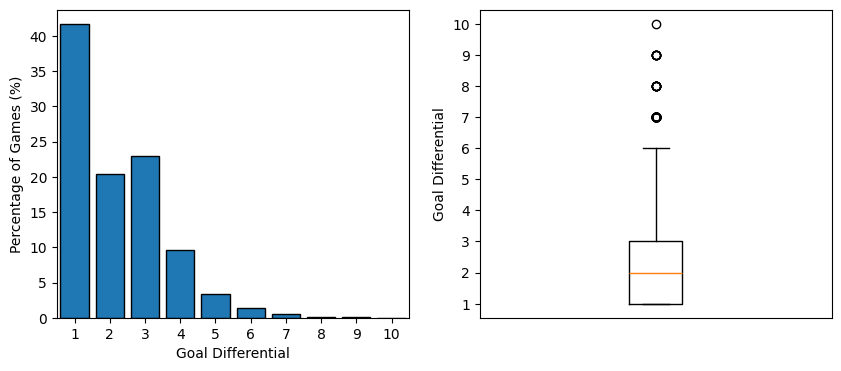

In [6]:
import matplotlib.pyplot as plt

# Let's only consider regular season games to avoid any noise/strange results from pre-season and 
games_raw_regular = games_raw[games_raw["gameType"] == 2]

games_raw_regular["goal_differential"] = abs(games_raw_regular["homeTeamScore"] -  games_raw_regular["awayTeamScore"])

goal_diff = games_raw_regular["goal_differential"]

# Plot
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,4))

# Histogram
bins = range(int(min(goal_diff)), int(max(goal_diff)) + 2, 1)
weights = [100 / len(goal_diff)] * len(goal_diff)

n, bin_edges, patches = ax[0].hist(x=goal_diff, bins=bins, edgecolor='k', rwidth=0.8, weights=weights)

bin_midpoints = [(bin_edges[i] + bin_edges[i+1]) / 2 for i in range(len(bin_edges) - 1)] 

ax[0].set_xticks(bin_midpoints)
ax[0].set_xticklabels(list(range(int(min(goal_diff)),int(max(goal_diff)) + 1)))

ax[0].set_xlim([int(min(goal_diff)),int(max(goal_diff) + 1)])

ax[0].set_xlabel("Goal Differential")
ax[0].set_ylabel("Percentage of Games (%)")

# Boxplot
ax[1].boxplot(goal_diff)
ax[1].set_xticks([])
ax[1].set_yticks(list(range(int(min(goal_diff)),int(max(goal_diff)) + 1)))

ax[1].set_ylabel("Goal Differential")

plt.show()

We see that approximately 60% of games have a 1-2 goal differential, and up to 75% of values are up to a goal differential of 3. We also see that outliers begin after a goal differential of 6. 

Let's consider all that and implement some logic for our goal index, $G$ with goal differential represented as $N = |\text{goalDiff}|$.

$$
G = \begin{cases} 
1 & \text{if } N \leq 2  \\
1.1 & \text{if } N =3  \\
1.25 & \text{if } 4 \leq N \leq 5  \\
1.5 & \text{if }  N \geq 6  \\
\end{cases}
$$

## Overtime and Shootout Wins/Losses
A game going to overtime or shootout are indicators that is was a close game, therefore the updates should be smaller in magnitude to reflect this.

We will use a simple factor of $M$ to implement this.

$$
M = \begin{cases} 
1 & \text{if game finish in regular time}  \\
0.75 & \text{if game finish in overtime} \\
0.5 & \text{if game finish in shootout}  \\
\end{cases}
$$


# Putting it all together, the Elo system

We can combine all of the extensions and a slight change in notation to give the following where $H$ is the home team, and $A$ is the away team.

$$
E_H = \frac{1}{1 + 10 ^ {\frac{R_A - (R_H+H_{\text{adv}})}{400}}} \quad \text{and} \quad E_A = 1-E_H,
$$
with $H_{\text{adv}}=30$.
$$
S_H = \begin{cases} 
1 & \text{if team } H \text{ wins}  \\
0 & \text{if team } H \text{ loses}  \\
\end{cases} \quad \text{and} \quad S_A = 1 - S_H.
$$

Let $N = |\text{score}_H - \text{score}_A|$ be the goal differential. The goal index $G$ is defined by:

$$
G = \begin{cases} 
1 & \text{if } N \leq 2  \\
1.1 & \text{if } N =3  \\
1.25 & \text{if } 4 \leq N \leq 5  \\
1.5 & \text{if }  N \geq 6  \\
\end{cases}
$$

and define the OT/SO multiplier $M$ by

$$
M = \begin{cases} 
1 & \text{regulation}  \\
0.75 & \text{overtime} \\
0.5 & \text{shootout}  \\
\end{cases}
$$

The rating updates are:

$$
R_H \gets R_H + KGM(S_H - E_H),
$$

$$
R_A \gets R_A + KGM(S_A - E_A),
$$

with $K=20$.

# Calculating Elo ratings

With our system fully defined, we can move on to actually calculating Elo ratings over a season. Let's reload the data. 

In [7]:
games_raw = pd.read_csv(games_file_path())
games_raw['gameId'] = games_raw['gameId'].astype(str)

year = 2024
game_type = 2 # regular season

mask = (games_raw['gameId'].str.startswith(str(year))) & (games_raw['gameType'] == game_type)
games = games_raw[mask]

## Initializing teams

### Getting list of all the teams

In [8]:
teams_list = list(games["awayTeamAbbrev"].unique())
len(teams_list)

32

### Initial ratings
We will set each team to start with a rating of $R=1500$, and store ratings in a dictionary.

In [9]:
def initialize_ratings(teams_list, R_init=1500):
    ratings = {}
    for team in teams_list:
        ratings[team] = R_init
    
    return ratings

In [10]:
ratings = initialize_ratings(teams_list)
ratings

{'NJD': 1500,
 'BUF': 1500,
 'STL': 1500,
 'BOS': 1500,
 'CHI': 1500,
 'TOR': 1500,
 'NYR': 1500,
 'WPG': 1500,
 'CGY': 1500,
 'COL': 1500,
 'MTL': 1500,
 'LAK': 1500,
 'FLA': 1500,
 'PIT': 1500,
 'UTA': 1500,
 'DAL': 1500,
 'CBJ': 1500,
 'TBL': 1500,
 'PHI': 1500,
 'OTT': 1500,
 'NSH': 1500,
 'CAR': 1500,
 'NYI': 1500,
 'SEA': 1500,
 'ANA': 1500,
 'MIN': 1500,
 'DET': 1500,
 'VAN': 1500,
 'VGK': 1500,
 'SJS': 1500,
 'EDM': 1500,
 'WSH': 1500}

## Modify dataFrame to compute needed algoirthm inputs

In [11]:
games["homeTeamWin"] = games["homeTeamScore"] > games["awayTeamScore"]
games["goalDiff"] = abs(games["homeTeamScore"] - games["awayTeamScore"])
games.head()

,gameId,gameType,gameDate,gameState,awayTeamId,awayTeamAbbrev,awayTeamScore,homeTeamId,homeTeamAbbrev,homeTeamScore,lastPeriodType,sourceFile,homeTeamWin,goalDiff
12689,2024020001,2,2024-10-04,OFF,1,NJD,4.0,7,BUF,1.0,REG,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,False,3.0
12690,2024020002,2,2024-10-05,OFF,7,BUF,1.0,1,NJD,3.0,REG,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,True,2.0
12691,2024020003,2,2024-10-08,OFF,19,STL,3.0,55,SEA,2.0,REG,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,False,1.0
12692,2024020004,2,2024-10-08,OFF,6,BOS,4.0,13,FLA,6.0,REG,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,True,2.0
12693,2024020005,2,2024-10-08,OFF,16,CHI,2.0,59,UTA,5.0,REG,B:\repos\nhl-playoff-pool-optimizer\data\raw\2...,True,3.0


## Elo functions


In [12]:
import numpy as np

def elo_expected_probabilities(R_h, R_a, h_adv=30):
    E_h = 1 / (1 + 10**((R_a - (R_h + h_adv))/400))
    E_a = 1 - E_h
    return E_h, E_a

def elo_score(home_team_win):
    #returns S_h, S_a
    return home_team_win, 1-home_team_win

def elo_goal_index(N):
    if N <= 2:
        return 1
    elif N == 3:
        return 1.1
    elif N >= 4 and N <= 5:
        return 1.25
    else:
        return 1.5

def elo_OT_SO_factor(last_period_type):
    if last_period_type == "REG":
        return 1
    elif last_period_type == "OT":
        return 0.75
    elif last_period_type == "SO":
        return 0.5

def elo_update_home_rating(R_h, E_h, S_h, G, M, K=20):
    return float(R_h + K*G*M*(S_h - E_h))

def elo_update_away_rating(R_a, E_a, S_a, G, M, K=20):
    return float(R_a + K*G*M*(S_a - E_a))

def elo_update_ratings(row, ratings, K=20, h_adv=30):
    # Extract team information
    abbrev_h = row["homeTeamAbbrev"]
    abbrev_a = row["awayTeamAbbrev"]
    
    # Get current ratings
    R_h = ratings[abbrev_h]
    R_a = ratings[abbrev_a]
    
    # Expected probabilities
    E_h, E_a = elo_expected_probabilities(R_h, R_a, h_adv=h_adv)
    
    # Outcome
    S_h, S_a = elo_score(row["homeTeamWin"])
    
    # Factors
    G = elo_goal_index(row["goalDiff"])
    M = elo_OT_SO_factor(row["lastPeriodType"])
    
    # Updates
    R_h = elo_update_home_rating(R_h, E_h, S_h, G, M, K=K)
    R_a = elo_update_away_rating(R_a, E_a, S_a, G, M, K=K)
    
    ratings[abbrev_h] = R_h
    ratings[abbrev_a] = R_a

    return ratings

### Run it for one game

In [13]:
ratings = initialize_ratings(teams_list)
row = games.iloc[0]
elo_update_ratings(row, ratings, K=20, h_adv=30)

{'NJD': 1511.9474628244886,
 'BUF': 1488.0525371755114,
 'STL': 1500,
 'BOS': 1500,
 'CHI': 1500,
 'TOR': 1500,
 'NYR': 1500,
 'WPG': 1500,
 'CGY': 1500,
 'COL': 1500,
 'MTL': 1500,
 'LAK': 1500,
 'FLA': 1500,
 'PIT': 1500,
 'UTA': 1500,
 'DAL': 1500,
 'CBJ': 1500,
 'TBL': 1500,
 'PHI': 1500,
 'OTT': 1500,
 'NSH': 1500,
 'CAR': 1500,
 'NYI': 1500,
 'SEA': 1500,
 'ANA': 1500,
 'MIN': 1500,
 'DET': 1500,
 'VAN': 1500,
 'VGK': 1500,
 'SJS': 1500,
 'EDM': 1500,
 'WSH': 1500}

### Sanity check

An interesting part of the Elo system, is that given no new players are added the mean rating will always be $R_\text{init}$.


In [14]:
def mean_rating(ratings):
    n = len(ratings)
    total = 0
    for key in ratings:
        total += ratings[key]
    return total/n

In [15]:
mean_rating(ratings)

1500.0

# Running the system

Let's run it for the 2024-2025 regular season.

In [16]:
ratings = initialize_ratings(teams_list)

for _, row in games.iterrows():
    ratings = elo_update_ratings(row, ratings)

In [17]:
from nhl_pool.config import PROCESSED_DIR
import json

# Reshape the dict to make this a dataframe
def ratings_dict_to_df(ratings_dict):
    teams = list(ratings_dict.keys())
    ratings = list(ratings_dict.values())
    data = {"teamAbbrev": teams, "rating": ratings}
    return pd.DataFrame(data)


ratings_save_path = PROCESSED_DIR / "20242025" / "regular" / "ratings.json"
with open(ratings_save_path, 'w') as json_file:
    json.dump(ratings, json_file, indent=4) 
    
ratings_df = ratings_dict_to_df(ratings)
ratings_df["elo_rank"] = ratings_df["rating"].rank(ascending=False).astype(int)

ratings_df_save_path = PROCESSED_DIR / "20242025" / "regular" / "ratings.csv"
ratings_df.to_csv(ratings_df_save_path, index=False)

ratings_df.sort_values(by="rating", ascending=False)

,teamAbbrev,rating,elo_rank
7,WPG,1619.056467,1
5,TOR,1609.960587,2
11,LAK,1599.869543,3
28,VGK,1583.516920,4
9,COL,1581.770093,5
2,STL,1575.148586,6
17,TBL,1564.061562,7
30,EDM,1552.455675,8
15,DAL,1545.816747,9
19,OTT,1543.936735,10


In [18]:
mean_rating(ratings)

1499.9999999999998

## How does this compare to the actual standings?



In [19]:
from nhl_pool.config import PROCESSED_DIR
standings_path = PROCESSED_DIR / "20242025"/ "regular" /"standings.csv"

standings = pd.read_csv(standings_path)

standings = pd.merge(standings, ratings_df, how="left", on="teamAbbrev")

standings.head()


,teamAbbrev,wins,losses,overtimeLosses,points,goalsFor,goalsAgainst,goalsDiff,regulationWins,overtimeWins,regulationAndOvertimeWins,rank,rating,elo_rank
0,WPG,56,22,4,116,277.0,191.0,86.0,43,11,54,1,1619.056467,1
1,WSH,51,22,9,111,288.0,232.0,56.0,43,6,49,2,1536.390717,11
2,VGK,50,22,10,110,275.0,219.0,56.0,46,3,49,3,1583.516920,4
3,TOR,52,26,4,108,268.0,231.0,37.0,41,10,51,4,1609.960587,2
4,DAL,50,26,6,106,277.0,224.0,53.0,41,7,48,5,1545.816747,9


In [20]:
standings[["teamAbbrev", "rank", "elo_rank"]]

,teamAbbrev,rank,elo_rank
0,WPG,1,1
1,WSH,2,11
2,VGK,3,4
3,TOR,4,2
4,DAL,5,9
5,LAK,6,3
6,TBL,7,7
7,COL,7,5
8,EDM,9,8
9,CAR,10,12


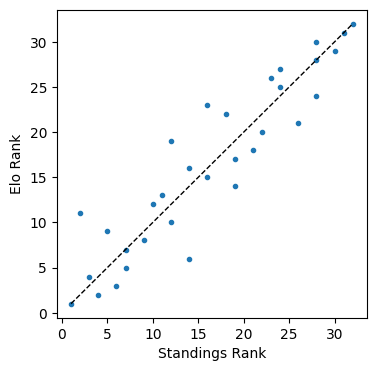

In [21]:
fig, ax = plt.subplots(figsize=(4,4))
ax.plot(standings["rank"], standings["elo_rank"], '.')

ax.plot([1,32], [1,32], '--', color='k', linewidth=1)

ax.set_xlabel("Standings Rank")
ax.set_ylabel("Elo Rank")

plt.show()

There seems to be some deviation around mid-tier teams. This seems reasonable since they are probably of similar strengths.

Let's make a histogram of the Elo ratings.

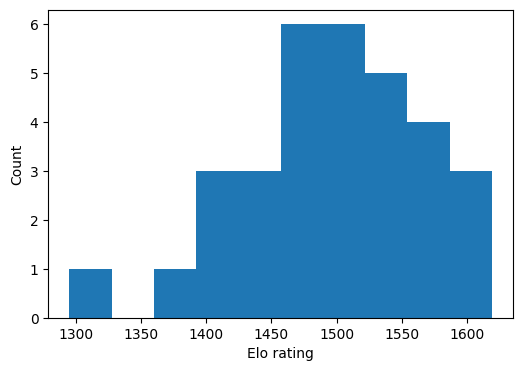

In [22]:
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(standings["rating"])

ax.set_xlabel("Elo rating")
ax.set_ylabel("Count")

plt.show()

We can see that there are the a lot of teams with a rating around 1500, so it seems plausible that teams that have a lot wins or very few wins more closely match in the two rankings.

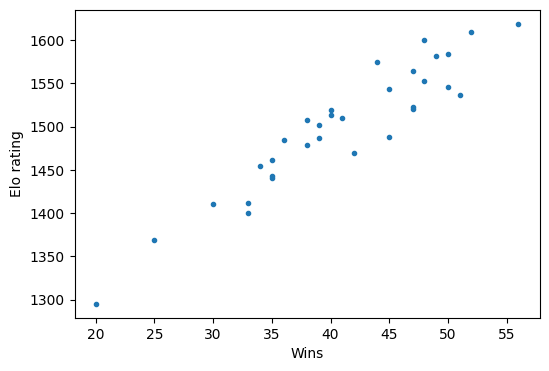

In [23]:
fig, ax = plt.subplots(figsize=(6,4))
ax.plot(standings["wins"], standings["rating"], '.')
ax.set_xlabel("Wins")
ax.set_ylabel("Elo rating")
plt.show()

Given these figures, we can conclude that the parameters to make the Elo system are reasonable. We do not expect the season standings ranking and the Elo ranking to match one-to-one. We do see the general trend of more wins -> higher Elo rating. 

# Validating
We want to make sure these parameters and Elo ratings actually perform okay.

Let's run the Elo rating again for the first 80% of a season, and then use the remaining 20% of the season as validation.

Note that we need the data to be in chronological order, so no randomized splitting.

## Read in data again

In [24]:
games_raw = pd.read_csv(games_file_path())
games_raw['gameId'] = games_raw['gameId'].astype(str)

year = 2024
game_type = 2 # regular season

mask = (games_raw['gameId'].str.startswith(str(year))) & (games_raw['gameType'] == game_type)
games = games_raw[mask]

games["homeTeamWin"] = games["homeTeamScore"] > games["awayTeamScore"]
games["goalDiff"] = abs(games["homeTeamScore"] - games["awayTeamScore"])

# Split
valid_frac = 0.2

split_idx = int((1-valid_frac) * len(games))

train_games = games.iloc[:split_idx]
valid_games = games.iloc[split_idx:]

In [25]:
ratings = initialize_ratings(teams_list)

h_adv=30
K=20
pred_rows = []

for i, row in games.iterrows():
    # Extract team information
    abbrev_h = row["homeTeamAbbrev"]
    abbrev_a = row["awayTeamAbbrev"]
    
    # Get current ratings
    R_h = ratings[abbrev_h]
    R_a = ratings[abbrev_a]
    
    # Expected probabilities
    E_h, E_a = elo_expected_probabilities(R_h, R_a, h_adv=h_adv)
    
    # Outcome
    S_h, S_a = elo_score(row["homeTeamWin"])
    
    # VALIDATION
    if i >= split_idx:
        pred_rows.append({"E_home": E_h, "S_home":S_h})
    
    # Factors
    G = elo_goal_index(row["goalDiff"])
    M = elo_OT_SO_factor(row["lastPeriodType"])
    
    # Updates
    R_h = elo_update_home_rating(R_h, E_h, S_h, G, M, K=K)
    R_a = elo_update_away_rating(R_a, E_a, S_a, G, M, K=K)
    
    ratings[abbrev_h] = R_h
    ratings[abbrev_a] = R_a

preds = pd.DataFrame(pred_rows)

Use log-loss of the prediction to actual outcome. We expect our Elo predictions to outperform a coin-flip result, and to outperform the home advantage as well.

In [26]:
import numpy as np
def log_loss(p, y):
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

In [27]:
# Elo
p = preds["E_home"].to_numpy()
y = preds["S_home"].to_numpy()

logloss = log_loss(p, y)

print(f"log-loss Elo: {logloss:.8f}")

# Coin flip
p_coin = 0.5
logloss_coin = log_loss(np.ones_like(y)*p_coin, y)
print(f"log-loss Coin: {logloss_coin:.8f}")

# Home win
p_home_win_rate = np.mean(train_games["homeTeamWin"])
logloss_hwr = log_loss(np.ones_like(y)*p_home_win_rate, y)
print(f"log-loss home win rate: {logloss_hwr:.8f}")


log-loss Elo: 0.67724115
log-loss Coin: 0.69314718
log-loss home win rate: 0.68546543


The Elo log-loss is lower than both the coin flip and the home win rates, so we can conclude that this is satisfactory as a baseline Elo rating implementation.

# Takeaway Notes and Future Work

It would be interesting to calculate the ELO over a small number of seasons. We can acknowledge that teams don't start completely fresh each season at the same strength. We can use the previous season to help initialize for the next season. Don't just use their old ranking, but as a factor in a new initialization.

It would be good to try and do a grid-search style of parameter optimization for $K$, $G$, and $M$. Could do a similar validation as above and choose the parameters which give the smallest log-loss.